In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import pandas as pd

import torch
from torch.nn import functional as F

from sklearn.metrics import auc
from neurovlm.metrics import recall_curve
from neurovlm.data import data_dir, load_dataset, load_masker, load_latent
from neurovlm.models import load_model

## NeuroVLM

In [2]:
# Load masker
masker = load_masker()

# Load dataframes
df_coords = load_dataset("pubmed_coordinates")
df_pubs = load_dataset("pubmed_text")
df_pubs = df_pubs[df_pubs['test']]
df_pubs = df_pubs.sort_values(by="pmid")
assert (df_pubs["pmid"] == df_pubs["pmid"].sort_values()).all()

# Load latent
latent_text, pmids_text = load_latent("pubmed_text")
latent_images, pmids_images = load_latent("pubmed_images")

assert np.all(pmids_text == np.sort(pmids_text))
assert np.all(pmids_images == np.sort(pmids_images))

# Index test pmids
mask_text = pd.Series(pmids_text).isin(df_pubs["pmid"])
mask_images = pd.Series(pmids_images).isin(df_pubs["pmid"])

latent_text, pmids_text = latent_text[mask_text], pmids_text[mask_text]
latent_images, pmids_images = latent_images[mask_images], pmids_images[mask_images]

assert np.all(df_pubs["pmid"] == pmids_text)
assert np.all(df_pubs["pmid"] == pmids_images)
assert np.all(pmids_text == pmids_images)

# Load pre-trained models
autoencoder = load_model("autoencoder")
proj_head_text = load_model("proj_head_text_infonce")
proj_head_image = load_model("proj_head_image_infonce")

In [3]:
# Contrastive projection
with torch.no_grad():
    latent_text_proj = F.normalize(proj_head_text(F.normalize(latent_text, dim=1)), dim=1)
    latent_images_proj = F.normalize(proj_head_image(latent_images), dim=1)

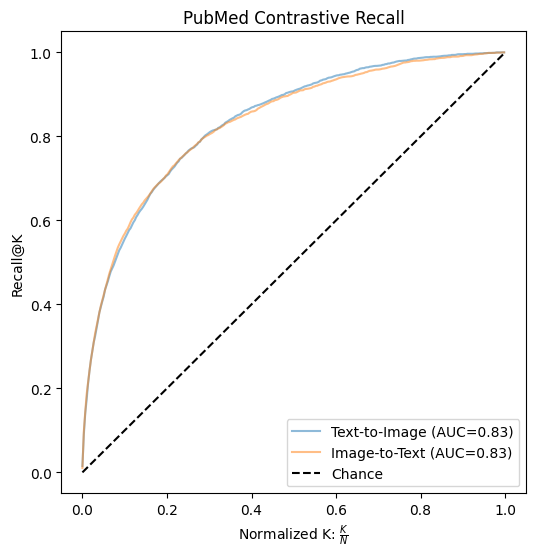

In [4]:
# Plot
step=10

t_to_i, i_to_t = recall_curve(latent_text_proj, latent_images_proj, step=step)

x = np.arange(0, len(latent_images_proj), step) / len(latent_images_proj)

auc_t_to_i = 0
auc_i_to_t = 0

auc_t_to_i = auc(x, t_to_i)
auc_i_to_t = auc(x, i_to_t)

fig, ax = plt.subplots(figsize=(6, 6))

label=f"Text-to-Image (AUC={round(auc_t_to_i, 2)})"
ax.plot(x, t_to_i, label=label, color="C0", alpha=0.5)

label=f"Image-to-Text (AUC={round(auc_i_to_t, 2)})"
ax.plot(x, i_to_t, label=label, color="C1", alpha=0.5)
ax.plot([0, 1], [0, 1], color='k', ls='--', label="Chance")
ax.set_xlabel(r"Normalized K: $\frac{K}{N}$")
ax.set_ylabel("Recall@K")
ax.set_title("PubMed Contrastive Recall")
plt.legend();

## NiCLIP and NeuroConText

Both models are CLIP-based and share the same image input format (DiFuMo-512), but use different text encoders:

| Model | Image features | Text encoder |
|---|---|---|
| NiCLIP | DiFuMo-512 (coordinate-based MKDA maps) | BrainGPT-7B-v0.2 (4096-dim mean-pooled last hidden state) |
| NeuroConText | DiFuMo-512 (coordinate-based MKDA maps) | Mistral-7B-v0.1 (4096-dim, context window 8,192 tokens; paper §2) |

All evaluations use the **fair subset**: papers in our test set that were **not** in the NiCLIP/NeuroConText training set (avoiding data leakage).

In [5]:
images, pmids_images = load_dataset("pubmed_images")
assert np.all(pmids_images == np.sort(pmids_images))

In [6]:
mask = pd.Series(pmids_images).isin(df_pubs["pmid"])
images = images[mask]
pmids_images = pmids_images[mask]
assert np.all(pmids_images == df_pubs["pmid"])

In [7]:
import os
import torch.nn as nn
from tqdm.auto import tqdm
from nilearn import datasets as nl_datasets
from nilearn.maskers import NiftiMapsMasker
from nilearn.image import concat_imgs

# ---------------------------------------------------------------------------
# Shared CLIP building blocks (mirrored from brain-decoder/braindec/model.py
# and NeuroConText/layers.py — identical architecture).
# ---------------------------------------------------------------------------

class _ResHead(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.gelu = nn.GELU()
        self.fc = nn.Linear(dim, dim)
        self.dropout = nn.Dropout(0.1)
        self.layer_norm = nn.LayerNorm(dim)

    def forward(self, x):
        out = self.fc(x)
        out = self.gelu(out)
        out = self.dropout(out)
        out = x + out
        return self.layer_norm(out)


class _ProjHead(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.projection = nn.Linear(in_dim, out_dim)
        self.gelu = nn.GELU()
        self.fc = nn.Linear(out_dim, out_dim)
        self.dropout = nn.Dropout(0.1)
        self.layer_norm = nn.LayerNorm(out_dim)

    def forward(self, x):
        projected = self.projection(x)
        x = self.gelu(projected)
        x = self.fc(x)
        x = self.dropout(x)
        x = x + projected
        return self.layer_norm(x)


# ---------------------------------------------------------------------------
# NiCLIP: state-dict keys have an extra ".model." level
#   image_model.model.{0,1,2}.fc.weight
#   text_model.model.0.projection.weight  ...
# ---------------------------------------------------------------------------

class _NiImageModel(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.model = nn.Sequential(_ResHead(dim), _ResHead(dim), _ResHead(dim))

    def forward(self, x):
        return self.model(x)


class _NiTextModel(nn.Module):
    def __init__(self, text_dim, out_dim):
        super().__init__()
        self.model = nn.Sequential(_ProjHead(text_dim, out_dim), _ResHead(out_dim), _ResHead(out_dim))

    def forward(self, x):
        return self.model(x)


class _NiCLIP(nn.Module):
    def __init__(self, text_dim, img_dim):
        super().__init__()
        self.image_model = _NiImageModel(img_dim)
        self.text_model = _NiTextModel(text_dim, img_dim)
        self.logit_scale = nn.Parameter(torch.ones([]))

    def encode_image(self, x):
        return F.normalize(self.image_model(x), dim=1)

    def encode_text(self, x):
        return F.normalize(self.text_model(x), dim=1)


def _load_niclip(path):
    sd = torch.load(path, weights_only=True, map_location="cpu")
    text_dim = sd["text_model.model.0.projection.weight"].shape[1]
    img_dim  = sd["image_model.model.0.fc.weight"].shape[1]
    model = _NiCLIP(text_dim, img_dim)
    model.load_state_dict(sd)
    return model.eval()


# ---------------------------------------------------------------------------
# NeuroConText: Sequential passed directly, so keys have no ".model." level
#   image_model.0.fc.weight
#   text_model.0.projection.weight  ...
# ---------------------------------------------------------------------------

class _NCImageModel(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.image_model = nn.Sequential(_ResHead(dim), _ResHead(dim), _ResHead(dim))

    def encode_image(self, x):
        return F.normalize(self.image_model(x), dim=1)


class _NCTextModel(nn.Module):
    def __init__(self, text_dim, out_dim):
        super().__init__()
        self.text_model = nn.Sequential(_ProjHead(text_dim, out_dim), _ResHead(out_dim), _ResHead(out_dim))

    def encode_text(self, x):
        return F.normalize(self.text_model(x), dim=1)


class _NeuroConText(nn.Module):
    def __init__(self, text_dim, img_dim):
        super().__init__()
        self.image_model = nn.Sequential(_ResHead(img_dim), _ResHead(img_dim), _ResHead(img_dim))
        self.text_model  = nn.Sequential(_ProjHead(text_dim, img_dim), _ResHead(img_dim), _ResHead(img_dim))
        self.logit_scale = nn.Parameter(torch.ones([]))

    def encode_image(self, x):
        return F.normalize(self.image_model(x), dim=1)

    def encode_text(self, x):
        return F.normalize(self.text_model(x), dim=1)


def _load_neurocontext(path):
    sd = torch.load(path, weights_only=True, map_location="cpu")
    text_dim = sd["text_model.0.projection.weight"].shape[1]
    img_dim  = sd["image_model.0.fc.weight"].shape[1]
    model = _NeuroConText(text_dim, img_dim)
    model.load_state_dict(sd)
    return model.eval()


print("Model builders defined.")

Model builders defined.


In [8]:
from pathlib import Path
if not Path("img_emb_512.pt").exists():
    # Inverse-transform masked images back to NiFTi (MNI152 2mm space)
    print("Inverse-transforming images to NiFTi...")
    nifti_imgs = concat_imgs([masker.inverse_transform(img.numpy()) for img in images])
    print(f"4D image shape: {nifti_imgs.shape}")

    # DiFuMo-512 — used by both NiCLIP and NeuroConText
    # (confirmed from NeuroConText preprocessed_test_gaussian_embeddings.pkl: shape (N, 512))
    print("Fetching DiFuMo-512 atlas and computing image embeddings...")
    difumo_512 = nl_datasets.fetch_atlas_difumo(dimension=512, resolution_mm=2)
    masker_512 = NiftiMapsMasker(maps_img=difumo_512.maps).fit()
    img_emb_512 = torch.tensor(masker_512.transform(nifti_imgs), dtype=torch.float32)
    print(f"Image embeddings (DiFuMo-512): {img_emb_512.shape}")

    torch.save(img_emb_512, "img_emb_512.pt")
    nib.save(difumo_512, "difumo_512.nii.gz")
else:
    img_emb_512 = torch.load("img_emb_512.pt")

In [9]:
import pickle
import numpy as np

# NiCLIP training PMIDs: extracted from the GCLDA baseline model
# (model-gclda_cogatlasred...pkl), which was fit on NiCLIP's training split.
# .ids are "{PMID}-{experiment}" strings; extracting the PMID gives exactly
# which papers NiCLIP saw during training.
_niclip_train_pmids = set(np.load("/home/rph/neurovlm/baseline/niclip_train_pmids.npy").tolist())

# NeuroConText training PMIDs
with open("/home/rph/neurovlm/NeuroConText/data/data_NeuroConText/train_pmids.pkl", "rb") as f:
    _nc_train_pmids = set(map(int, pickle.load(f)))

_our_pmids = df_pubs["pmid"].tolist()
_in_niclip_train = np.array([p in _niclip_train_pmids for p in _our_pmids])
_in_nc_train     = np.array([p in _nc_train_pmids     for p in _our_pmids])
_in_either_train = _in_niclip_train | _in_nc_train
_fair = ~_in_either_train

print(f"Our test papers                   : {len(_our_pmids)}")
print(f"NiCLIP train set                  : {len(_niclip_train_pmids)} papers")
print(f"NC train set                      : {len(_nc_train_pmids)} papers")
print(f"In NiCLIP train                   : {_in_niclip_train.sum()}  ({100*_in_niclip_train.mean():.1f}%)")
print(f"In NC train                       : {_in_nc_train.sum()}  ({100*_in_nc_train.mean():.1f}%)")
print(f"In either train                   : {_in_either_train.sum()}  ({100*_in_either_train.mean():.1f}%)")
print(f"Fair subset (in neither)          : {_fair.sum()}  ({100*_fair.mean():.1f}%)")

fair_mask = torch.tensor(_fair)


Our test papers                   : 2987
NiCLIP train set                  : 21790 papers
NC train set                      : 19674 papers
In NiCLIP train                   : 2033  (68.1%)
In NC train                       : 1907  (63.8%)
In either train                   : 2619  (87.7%)
Fair subset (in neither)          : 368  (12.3%)


In [10]:
# NeuroVLM — same fair subset used for all models
t_to_i_nvlm, i_to_t_nvlm = recall_curve(
    latent_text_proj[fair_mask], latent_images_proj[fair_mask], step=step
)
n_fair = int(fair_mask.sum())
x_fair = np.arange(0, n_fair, step) / n_fair
auc_t_to_i_nvlm = auc(x_fair, t_to_i_nvlm)
auc_i_to_t_nvlm = auc(x_fair, i_to_t_nvlm)
print(f"NeuroVLM (fair subset n={n_fair})  T→I: {auc_t_to_i_nvlm:.3f}   I→T: {auc_i_to_t_nvlm:.3f}")

NeuroVLM (fair subset n=368)  T→I: 0.829   I→T: 0.830


In [11]:
from peft import PeftConfig, PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer

# Cached to avoid re-running the 7B model on every notebook execution.
# NiCLIP was trained with section="body"; we use title+abstract as an approximation.
_BRAINGPT_CACHE = "/home/rph/neurovlm/docs/03_evaluation/braingpt_embeddings.pt"

if os.path.exists(_BRAINGPT_CACHE):
    txt_emb_braingpt = torch.load(_BRAINGPT_CACHE, weights_only=True, map_location="cpu")
    print(f"Loaded BrainGPT embeddings from cache: {txt_emb_braingpt.shape}")
else:
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Embedding {len(df_pubs)} texts with BrainGPT-7B-v0.2 on {device} ...")

    config = PeftConfig.from_pretrained("BrainGPT/BrainGPT-7B-v0.2")
    _base = AutoModelForCausalLM.from_pretrained("mistralai/Mistral-7B-v0.1")
    _bg_model = PeftModel.from_pretrained(_base, "BrainGPT/BrainGPT-7B-v0.2").eval().to(device)

    _tokenizer = AutoTokenizer.from_pretrained("mistralai/Mistral-7B-v0.1")
    _tokenizer.pad_token = _tokenizer.eos_token

    texts = (df_pubs["name"] + " [SEP] " + df_pubs["description"]).tolist()

    _batch_size = 4
    _all_embs = []
    for i in tqdm(range(0, len(texts), _batch_size), desc="BrainGPT"):
        batch = texts[i : i + _batch_size]
        enc = _tokenizer(batch, return_tensors="pt", padding=True,
                         truncation=True, max_length=4096)
        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad():
            out = _bg_model(**enc, output_hidden_states=True)
            h = out.hidden_states[-1]                      # (B, T, D)
            m = enc["attention_mask"].unsqueeze(-1).float()
            emb = (h * m).sum(1) / m.sum(1).clamp(min=1e-9)
        _all_embs.append(emb.cpu().float())

    txt_emb_braingpt = torch.cat(_all_embs, dim=0)
    torch.save(txt_emb_braingpt, _BRAINGPT_CACHE)
    print(f"Saved BrainGPT embeddings: {txt_emb_braingpt.shape}")

    del _bg_model, _base
    if device == "cuda":
        torch.cuda.empty_cache()

print(f"BrainGPT text embeddings: {txt_emb_braingpt.shape}")  # (N, 4096)

Loaded BrainGPT embeddings from cache: torch.Size([2987, 4096])
BrainGPT text embeddings: torch.Size([2987, 4096])


In [12]:
# Mistral-7B-v0.1 text embeddings for NeuroConText
# (NeuroConText paper §2: "we use Mistral-7B with a context window of 8,192 tokens")
_MISTRAL_CACHE = "/home/rph/neurovlm/docs/03_evaluation/mistral_embeddings.pt"

if os.path.exists(_MISTRAL_CACHE):
    txt_emb_mistral = torch.load(_MISTRAL_CACHE, weights_only=True, map_location="cpu")
    print(f"Loaded Mistral-7B embeddings from cache: {txt_emb_mistral.shape}")
else:
    from transformers import AutoModelForCausalLM, AutoTokenizer
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Embedding {len(df_pubs)} texts with Mistral-7B-v0.1 on {device} ...")

    _m_model = AutoModelForCausalLM.from_pretrained("mistralai/Mistral-7B-v0.1").eval().to(device)
    _m_tok   = AutoTokenizer.from_pretrained("mistralai/Mistral-7B-v0.1")
    _m_tok.pad_token = _m_tok.eos_token

    texts = (df_pubs["name"] + " [SEP] " + df_pubs["description"]).tolist()

    _all_embs = []
    for i in tqdm(range(0, len(texts), 4), desc="Mistral-7B"):
        batch = texts[i : i + 4]
        enc = _m_tok(batch, return_tensors="pt", padding=True,
                     truncation=True, max_length=8192)
        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad():
            out = _m_model(**enc, output_hidden_states=True)
            h = out.hidden_states[-1]
            m = enc["attention_mask"].unsqueeze(-1).float()
            emb = (h * m).sum(1) / m.sum(1).clamp(min=1e-9)
        _all_embs.append(emb.cpu().float())

    txt_emb_mistral = torch.cat(_all_embs, dim=0)
    torch.save(txt_emb_mistral, _MISTRAL_CACHE)
    print(f"Saved Mistral-7B embeddings: {txt_emb_mistral.shape}")

    del _m_model
    if device == "cuda":
        torch.cuda.empty_cache()

print(f"Mistral-7B text embeddings: {txt_emb_mistral.shape}")  # (N, 4096)

# NeuroConText text preprocessing pipeline:
# NC trained on: Mistral-7B mean-pool → L2-normalize → StandardScaler(fit on train).
# Verified by applying pipeline to NC's test_text_embeddings.pkl → matches preprocessed_test_text_embeddings.pkl exactly.
# We embed title+abstract (NC likely used body text); norms differ (~98 vs ~64) due to text content
# difference, but the per-feature centering/scaling is correctly applied.
import pickle, warnings
warnings.filterwarnings("ignore")

_NC_PIPELINE = "/home/rph/neurovlm/NeuroConText/data/data_NeuroConText/text_preprocessing_pipeline.pkl"
with open(_NC_PIPELINE, "rb") as _f:
    _nc_text_pipeline = pickle.load(_f)

# Step 1: L2-normalize (NC's raw text embeddings have norms ~1.0)
txt_emb_mistral_l2 = F.normalize(txt_emb_mistral, dim=1)
# Step 2: Apply StandardScaler (per-feature centering+scaling matched to NC training distribution)
nc_txt_input = torch.tensor(
    _nc_text_pipeline.transform(txt_emb_mistral_l2.numpy()).astype("float32")
)
print(f"NC text input (after L2 + StandardScaler): {nc_txt_input.shape}, mean norm: {nc_txt_input.norm(dim=1).mean():.1f}")

Loaded Mistral-7B embeddings from cache: torch.Size([2987, 4096])
Mistral-7B text embeddings: torch.Size([2987, 4096])
NC text input (after L2 + StandardScaler): torch.Size([2987, 4096]), mean norm: 98.5


In [13]:
# NiCLIP — evaluated on papers NOT in its training set (fair_mask)
niclip = _load_niclip("/home/rph/neurovlm/pubmed/model-clip_section-body_embedding-BrainGPT-7B-v0.2_best.pth")

with torch.no_grad():
    niclip_img_emb = niclip.encode_image(img_emb_512[fair_mask])
    niclip_txt_emb = niclip.encode_text(txt_emb_braingpt[fair_mask])

t_to_i_niclip, i_to_t_niclip = recall_curve(niclip_txt_emb, niclip_img_emb, step=step)
auc_t_to_i_niclip = auc(x_fair, t_to_i_niclip)
auc_i_to_t_niclip = auc(x_fair, i_to_t_niclip)
print(f"NiCLIP (fair subset n={fair_mask.sum()})  T→I: {auc_t_to_i_niclip:.3f}   I→T: {auc_i_to_t_niclip:.3f}")

NiCLIP (fair subset n=368)  T→I: 0.817   I→T: 0.801


### NeuroConText

Pre-trained checkpoint at `/home/rph/neurovlm/NeuroConText/best_val.pt`.

In [14]:
NEUROCONTEXT_CKPT = "/home/rph/neurovlm/NeuroConText/best_val.pt"

t_to_i_nc = i_to_t_nc = None
auc_t_to_i_nc = auc_i_to_t_nc = None

if os.path.exists(NEUROCONTEXT_CKPT):
    nc_model = _load_neurocontext(NEUROCONTEXT_CKPT)

    # fair_mask: papers not in NC/NiCLIP training set (based on NC train_pmids.pkl)
    # nc_txt_input: Mistral-7B → L2-normalize → StandardScaler (matches NC training preprocessing exactly)
    with torch.no_grad():
        nc_img_emb = nc_model.encode_image(img_emb_512[fair_mask])
        nc_txt_emb = nc_model.encode_text(nc_txt_input[fair_mask])

    t_to_i_nc, i_to_t_nc = recall_curve(nc_txt_emb, nc_img_emb, step=step)
    auc_t_to_i_nc = auc(x_fair, t_to_i_nc)
    auc_i_to_t_nc = auc(x_fair, i_to_t_nc)
    print(f"NeuroConText (fair subset n={fair_mask.sum()})  T→I: {auc_t_to_i_nc:.3f}   I→T: {auc_i_to_t_nc:.3f}")
else:
    print(f"Checkpoint not found: {NEUROCONTEXT_CKPT}")

NeuroConText (fair subset n=368)  T→I: 0.796   I→T: 0.807


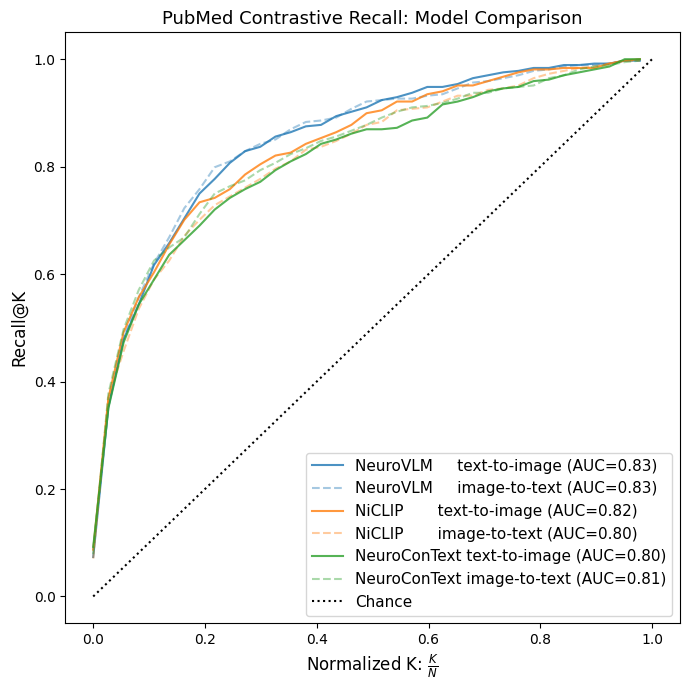

In [17]:
fig, ax = plt.subplots(figsize=(7, 7))

# All three models evaluated on the same fair subset (papers in neither NiCLIP nor NC training set)
ax.plot(x_fair, t_to_i_nvlm,
        label=f"NeuroVLM     text-to-image (AUC={auc_t_to_i_nvlm:.2f})", color="C0", alpha=0.8)
ax.plot(x_fair, i_to_t_nvlm,
        label=f"NeuroVLM     image-to-text (AUC={auc_i_to_t_nvlm:.2f})", color="C0", alpha=0.4, ls="--")

ax.plot(x_fair, t_to_i_niclip,
        label=f"NiCLIP       text-to-image (AUC={auc_t_to_i_niclip:.2f})", color="C1", alpha=0.8)
ax.plot(x_fair, i_to_t_niclip,
        label=f"NiCLIP       image-to-text (AUC={auc_i_to_t_niclip:.2f})", color="C1", alpha=0.4, ls="--")

if t_to_i_nc is not None:
    ax.plot(x_fair, t_to_i_nc,
            label=f"NeuroConText text-to-image (AUC={auc_t_to_i_nc:.2f})", color="C2", alpha=0.8)
    ax.plot(x_fair, i_to_t_nc,
            label=f"NeuroConText image-to-text (AUC={auc_i_to_t_nc:.2f})", color="C2", alpha=0.4, ls="--")

ax.plot([0, 1], [0, 1], color="k", ls=":", label="Chance")
ax.set_xlabel(r"Normalized K: $\frac{K}{N}$", fontsize=12)
ax.set_ylabel("Recall@K", fontsize=12)
ax.set_title(f"PubMed Contrastive Recall: Model Comparison", fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig("recall_comparison.svg", dpi=300, bbox_inches="tight")
plt.show()